# SPC: Sparse Principal Component Analysis

Sparse Principal Component Analysis or SPC can be considered as a variant of principal component analysis or PCA that, similar to PCA, finds the directions of greatest variance in a data matrix while enforcing an $L_1$ penalty on the loadings. Thus ensures that each component is supported by only a few variables.

In PCA, the principal components gives the direction of maximum variability of the centered data. Equivalently, the leading component solves $\max u' X v$ over unit vectors $u$ and $v$. Here every variable receives a nonzero loading. SPC keeps this variance maximizing criterion of PCA but adds a penalty on the loading vector $v$ only. This differntiates with with Penalized matrix decomosition which adds penalty at both, $u$ and $v$. In SPC, we consider the following optimization problem: $$\max u' X v \text{ subject to the constraint } ‖u‖_2 \le 1 \text{, } ‖v‖_2 \le 1 \text{, } P(v) \le c.$$ We consider the penalty $P$ to be an $l_1$(lasso) penalty. This produces sparsity as the $L_1$ budget forces many entries of $v$ to be exactly $0$, so each component is defined by only a small number of variables. The parameter in `spc`: `c` sets how large the $L_1$ norm of each loading will be in a range of $[1, \sqrt{p}]$. Here smaller values will give sparser loadings and $c = \sqrt{p}$ will recover PCA.

The optimization problem is solved by an alternating algorithm where we hold $v$ fixed and then set $u \leftarrow Xv$ (normalized). Then we hold $u$ fixed and solve for $v$ by soft-thresholding $X'u$ into the $L_1$ budget. We remove the additional components in `spc` by removing the fitted rank-one piece from $X$ and repeating them on the residual. This in the deflation of SVD. In `spc_orth`,we extract each component from the original centered matrix. We force its scores $u$ to be orthogonal to all previously extracted components. This provides us with an orthonormal set of score direction.


In this documentation, we will demonstrate implementation of SPC using `BigRiverEssence.spc` and `BigRiverEssence.spc_orth` on a breast cancer dataset.

## The method summary

- We will center the data matrix (and can optionally standardize it to unit variance).
- We will then find the leading principal directions, which are  the axes of the largest variance. However, unlike in PCA, we will consider an L1 penalty on each loading. This will forces most of its entries to be $0$. Hence we will gte each components to be described by only a few variables. 
- The penalty strength is set by `c` which is essentially the $L_1$ budget $\in [1, \sqrt{p}]$. Here a smaller `c` will give sparser loadings whereas `c` = $\sqrt{p}$ will recover ordinary  PCA.
- We will report the variance each sparse component carries and the cumulative proportion of total variance the components explain together.

This package provides two variants: `spc`, which extracts components by deflation, and `spc_orth`, which constrains the component scores to be mutually orthogonal.


## The data

We use the same breast cancer copy-number matrix as we used in the demonstration of  PMD. The matrix contains $89$ samples, each with $2149$ genomic spots. Here genomic spots are variables. We note that, here the number of variables are far larger than the number of samples. Using naive PCA will lead to components or directions each with all the variables, this will lead to probles involving over parameterization. Hence, this dataset is well suited for SPC which will consider only a few number of variables per components. 

In [ ]:
using BigRiverEssence
const BRE = BigRiverEssence
using RCall, Plots, Statistics
gr()

R"""
suppressMessages(library(PMA))
breast <- download_breast_data(url = "https://tibshirani.su.domains/PMA/breastdata.rda")
dna_t <- t(breast$dna)
chrom <- breast$chrom
"""
dna   = rcopy(R"dna_t")         # 89 × 2149
chrom = Int.(rcopy(R"chrom"))
size(dna)

┌ Warning: RCall.jl: trying URL 'https://tibshirani.su.domains/PMA/breastdata.rda'
│ Content type 'application/octet-stream' length 6619048 bytes (6.3 MB)
│ ==================================================
│ downloaded 6.3 MB
│ 
└ @ RCall /Users/abhisekbanerjee/.julia/packages/RCall/fTLHT/src/io.jl:166


(89, 2149)

## Fitting SPC

The function `spc` fits the deflation variant. We will consider $3$ components and will set `k = 3`. We will set the $L_1$budget
`c` way below $\sqrt{p}$ to enforce sparsity. We will standardize so every variable is on equal footing.

In [ ]:
c = sqrt(size(dna, 2)) / 4          # a fairly tight sparsity budget
m = BRE.spc(dna; k = 3, c = c, standardize = true)

spcStructure{Float64}([-0.11426617696629217, -0.061205915543071164, -0.015992490636704118, -0.05906398876404495, 0.297114263483146, -0.020601783146067414, -0.11310197378277154, -0.08603488539325842, -0.0648096404494382, -0.10934695730337077  …  -0.024352492696629206, -0.0630057732209738, -0.054137995505617986, -0.060265850936329586, -0.051899957677902626, -0.044060069101123596, -0.04495634400749064, -0.09287574943820226, -0.029689914044943814, -0.012148786516853931], [0.1586795899428074, 0.19893395432708758, 0.1831579379339093, 0.14645595489285992, 0.23719014143610448, 0.16282376043702984, 0.17950079477848177, 0.17172748652225894, 0.1909443747177343, 0.17171011746667825  …  0.18204515308338573, 0.17201613545923525, 0.1729248065580607, 0.17849777652237206, 0.18019620786593102, 0.15765141680055064, 0.18044357539937989, 0.17875071344712873, 0.1699336148544131, 0.13565384965898514], [-0.0 -0.0 -0.0; -0.0 -0.0 -0.0; … ; -0.0 -0.0 -0.0; -0.0 -0.0 -0.0], [57.86389427585375, 57.63181315139406,

## How much variance, and how sparse?

The main goal of SPC is to  capture variance with few variables only. We can quantify both using `propOFvar` and `loadings` of `spc`.


In [13]:
@show m.propOFvar[end]
@show [count(!iszero, m.loadings[:, j]) for j in 1:3]
@show [count(!iszero, m.loadings[:, j]) / size(dna, 2) for j in 1:3]

m.propOFvar[end] = 0.08091062149383325
[count(!iszero, m.loadings[:, j]) for j = 1:3] = [289, 192, 242]
[count(!iszero, m.loadings[:, j]) / size(dna, 2) for j = 1:3] = [0.13448115402512797, 0.0893438808748255, 0.11261051651931131]


3-element Vector{Float64}:
 0.13448115402512797
 0.0893438808748255
 0.11261051651931131


We can see from the above output, the three sparse components together explain about $8\%$ of the total variance, while each
uses only about $9–13\%$ of the $2149$ genomic spots. Every other loading is made $0$.

To get an idea of what the sparsity costs we can compare with ordinary PCA which we obtain by setting
the sparsity budget to its maximum value `c = √p`:

In [ ]:
m_dense = BRE.spc(dna; k = 3, c = sqrt(size(dna, 2)), standardize = true)
m_dense.propOFvar[end]

0.17510461215688392

We see that ordinary or dense PCA explains about $17.5\%$ with three components while using all the $2149$ variables in each. SPC
recovers little bit less than half of that variance while throwing away roughly $90\%$ of the variables. This shows that, when the signal is concentrated only at a few variables, SPC costs very less and when variation is spread across several variables, sparsity gives up more variance in return for components that are far easier to interpret. The budget `c` lets us decide on this trade off. 

## Visualizing a sparse component

In SPC, each loading of each component is sparse. Hence, if we plot it along the genome, it will show which
regions defines that principal direction. We can make a scatter plot of the two loadings to visualize this.

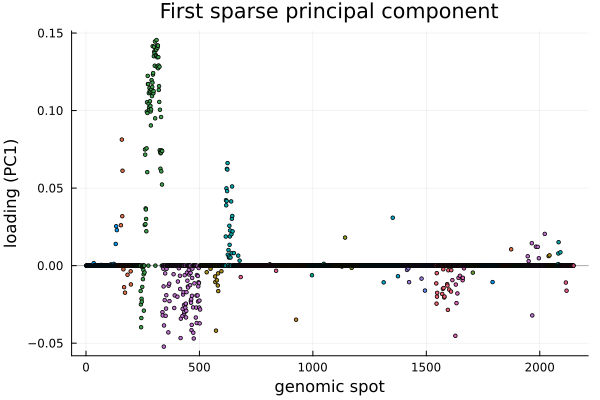

In [16]:
scatter(1:size(m.loadings, 1), m.loadings[:, 1]; group = chrom,
    markersize = 2, legend = false,
    xlabel = "genomic spot", ylabel = "loading (PC1)",
    title = "First sparse principal component")
hline!([0], color = :black, alpha = 0.3)

The first sparse principal component concentrates its loadings in a few genomic
regions — a strong cluster around spots 250–350, another near 600, and scattered
weaker regions elsewhere — while the large majority of the 2149 spots have loadings of
exactly zero (the flat line). So the leading axis of variation in this copy-number
data is described by a small set of chromosomal regions rather than by all the spots
at once. The colors mark chromosomes, so each cluster can be read off to the
chromosome it sits on.

## The orthogonal variant: `spc_orth`

The `spc` function extracts components by deflation. This cannot does enforce orthogonality of the component scores. `spc_orth`, on the other hand, adds this constraint where it ensures each component's scores are orthogonal to all previous one. This gives us an orthonormal set of score directions. Similar to `spc`, in `spc_orth` as well, we can get the proportion of variance explained with the few selected varibles and the loadings using `propOFvar` and `loadings` respectively. 

In [ ]:
mo = BRE.spc_orth(dna; k = 3, c = c, standardize = true)
@show mo.propOFvar[end]                                  # cumulative variance explained
@show [count(!iszero, mo.loadings[:, j]) for j in 1:3]  # number of non-zero loadings per component

mo.propOFvar[end] = 0.0806942828820599
[count(!iszero, mo.loadings[:, j]) for j = 1:3] = [289, 190, 224]


3-element Vector{Int64}:
 289
 190
 224

`spc_orth` returns the same `spcStructure` type, so we can read its fields exactly as
before. We can use `spc` when we want the simplest sparse components, and `spc_orth` when
orthogonal scores matter for downstream interpretation.

## Summary

 `spc` and  `spc_orth`is most suitable for wide matrices where the number of variables or columns are more than number of observations or rows. They noth produced a few sparse principal
components that capture much of the variance while each depending on only a small set
of variables. `spc_orth` offers in addion, orthogonal scores. Here we demonstrated the use of SPC using `spc` and `spc_orth` functions from the Julia package `BigRiverEssence.jl`. SPC can also be applied to any similar dataset.